In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time

In [ ]:
import subprocess
import sys
try:
    import selenium
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "selenium", "webdriver-manager"])
try:
    subprocess.run(['google-chrome', '--version'], check=True, capture_output=True)
except (subprocess.CalledProcessError, FileNotFoundError):
    print("Google Chrome not found, installing...")
    subprocess.check_call('wget -qO- https://dl-ssl.google.com/linux/linux_signing_key.pub | sudo tee /etc/apt/trusted.gpg.d/google-chrome.asc', shell=True)
    subprocess.check_call(['sudo', 'sh', '-c', 'echo "deb [arch=amd64] http://dl.google.com/linux/chrome/deb/ stable main" >> /etc/apt/sources.list.d/google-chrome.list'])
    subprocess.check_call(['sudo', 'apt-get', 'clean'])
    subprocess.check_call(['sudo', 'apt-get', 'update'])
    subprocess.check_call(['sudo', 'apt-get', 'install', '-f', '-y'])
    subprocess.check_call(['sudo', 'apt-get', 'install', '-y', 'google-chrome-stable'])
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")
options.add_argument("--disable-gpu")
options.add_argument("--window-size=1920,1080")
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

In [ ]:
fashion_keywords=[
    "dress", "skirt", "top", "blouse", "shirt", "t-shirt",
    "hoodie", "jacket", "coat", "sweater", "jeans", "pants",
    "leggings", "abaya", "hijab", "scarf", "swimwear",
    "bag", "handbag", "backpack", "shoes", "shoe", "sneakers",
    "heels", "heel", "boots", "sandals", "veil", "purse"
]
def get_category_from_text(name, link=""):
    text=(str(name) + " " + str(link)).lower()
    if any(word in text for word in ["hoodie", "jacket", "coat", "sweater", "cardigan", "blazer"]):
        return "Outerwear"
    elif any(word in text for word in ["dress", "gown"]):
        return "Dresses"
    elif any(word in text for word in ["skirt", "jeans", "pants", "leggings", "trousers", "shorts"]):
        return "Bottoms"
    elif any(word in text for word in ["top", "blouse", "shirt", "t-shirt", "tshirt", "tank"]):
        return "Tops"
    elif any(word in text for word in ["hijab", "scarf", "veil", "abaya", "kaftan", "shawl"]):
        return "Modest Wear"
    elif any(word in text for word in ["bag", "handbag", "backpack", "purse", "tote", "crossbody"]):
        return "Bags"
    elif any(word in text for word in ["shoe", "shoes", "sneaker", "sneakers", "boot", "boots", "heel", "heels", "sandals", "flats"]):
        return "Shoes"
    elif any(word in text for word in ["swimwear", "swimsuit", "bikini", "beachwear"]):
        return "Swimwear"
    else:
        return "Women Fashion"
def is_women_fashion(name, link=""):
    text=(str(name) + " " + str(link)).lower()
    return any(word in text for word in fashion_keywords)

# **BeautifulSoup**

In [ ]:
base_url="https://www.scrapingcourse.com/ecommerce/page/"
site_url="https://www.scrapingcourse.com"
headers={"User-Agent": "Mozilla/5.0"}
products=[]
keywords=[
    "dress", "skirt", "top", "blouse", "shirt", "t-shirt",
    "hoodie", "jacket", "coat", "sweater", "jeans", "pants",
    "leggings", "abaya", "hijab", "scarf", "swimwear",
    "bag", "handbag", "backpack", "shoes", "shoe", "sneakers",
    "heels", "heel", "boots", "sandals"
]
for page in range(1, 15):
    url=base_url + str(page)
    response=requests.get(url, headers=headers)
    if response.status_code != 200:
        continue
    soup=BeautifulSoup(response.text, "html.parser")
    items=soup.find_all("li", class_="product")
    for item in items:
        try:
            name=item.find("h2").text.strip()
            price=item.find("span", class_="price").text.strip()
            link=item.find("a")["href"]
            image=item.find("img")["src"]
            if link.startswith("/"):
                link=site_url + link
            if image.startswith("/"):
                image=site_url + image
            name_lower=name.lower()
            if is_women_fashion(name, link):
                products.append({
                    "Name": name,
                    "Price": price,
                    "Link": link,
                    "Image": image,
                    "Category": get_category_from_text(name, link),
                    "Source": "BeautifulSoup",
                    "Rating": np.nan,
                    "Reviews": 0
                })
        except:
            pass
    if len(products) >= 200:
        break
df_scraping=pd.DataFrame(products)
print("BeautifulSoup products:", len(df_scraping))
display(df_scraping.head(10))

BeautifulSoup products: 51


,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,Abominable Hoodie,$69.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
1,Adrienne Trek Jacket,$57.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
2,Ajax Full-Zip Sweatshirt,$69.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
3,Ariel Roll Sleeve Sweatshirt,$39.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
4,Augusta Pullover Jacket,$57.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
5,Bruno Compete Hoodie,$63.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
6,Cassia Funnel Sweatshirt,$48.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
7,Chaz Kangeroo Hoodie,$52.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
8,Crown Summit Backpack,$38.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Bags,BeautifulSoup,NaN,0
9,Daphne Full-Zip Hoodie,$59.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0


# **API**

In [ ]:
APP_ID="YOUR_API"
CERT_ID="YOUR_API"
target_total=3000
category_queries={
    "Dresses": [
        "women maxi dress", "women summer dress", "women evening dress",
        "women casual dress", "women floral dress", "women party dress"
    ],
    "Tops": [
        "women blouse", "women crop top", "women t shirt",
        "women tank top", "women long sleeve shirt", "women tunic top"
    ],
    "Bottoms": [
        "women jeans", "women leggings", "women skirt",
        "women pants", "women shorts", "women trousers"
    ],
    "Outerwear": [
        "women hoodie", "women jacket", "women coat",
        "women cardigan", "women blazer", "women sweater"
    ],
    "Bags": [
        "women handbag", "women tote bag", "women shoulder bag",
        "women backpack", "women purse", "women crossbody bag"
    ],
    "Shoes": [
        "women sneakers", "women boots", "women sandals",
        "women heels", "women flats", "women loafers"
    ],
    "Modest Wear": [
        "women hijab", "women scarf", "women abaya",
        "women modest dress", "women kaftan", "women shawl"
    ],
    "Swimwear": [
        "women swimwear", "women swimsuit", "women bikini",
        "women beachwear", "women cover up", "women one piece swimsuit"
    ]
}
target_per_category=target_total // len(category_queries)
def get_ebay_token():
    auth_str=APP_ID.strip() + ":" + CERT_ID.strip()
    encoded_auth=base64.b64encode(auth_str.encode("utf-8")).decode("utf-8")
    response=requests.post(
        "https://api.ebay.com/identity/v1/oauth2/token",
        headers={
            "Content-Type": "application/x-www-form-urlencoded",
            "Authorization": "Basic " + encoded_auth
        },
        data={
            "grant_type": "client_credentials",
            "scope": "https://api.ebay.com/oauth/api_scope"
        },
        timeout=20
    )
    if response.status_code==200:
        return response.json().get("access_token")
    print("Token error:", response.status_code)
    print(response.text[:300])
    return None
def search_ebay(keyword, token, limit=100, offset=0):
    response=requests.get(
        "https://api.ebay.com/buy/browse/v1/item_summary/search",
        headers={
            "Authorization": "Bearer " + token,
            "X-EBAY-C-MARKETPLACE-ID": "EBAY_US"
        },
        params={
            "q": keyword,
            "limit": limit,
            "offset": offset
        },
        timeout=30
    )
    if response.status_code!= 200:
        return []
    return response.json().get("itemSummaries", [])
token=get_ebay_token()
api_products=[]
seen=set()
if token:
    for category, queries in category_queries.items():
        category_count=0
        for keyword in queries:
            if category_count >= target_per_category:
                break
            for offset in range(0, 5000, 100):
                if category_count >= target_per_category:
                    break
                items=search_ebay(keyword, token, limit=100, offset=offset)
                if len(items)==0:
                    break
                for item in items:
                    if category_count >= target_per_category:
                        break
                    name=item.get("title", "")
                    price=item.get("price", {}).get("value", "")
                    currency=item.get("price", {}).get("currency", "")
                    link=item.get("itemWebUrl", "")
                    image=item.get("image", {}).get("imageUrl", "") if item.get("image") else ""
                    key=item.get("itemId", name + link)
                    if name and price and link and image and key not in seen:
                        seen.add(key)
                        api_products.append({
                            "Name": name,
                            "Price": price,
                            "Currency": currency,
                            "Link": link,
                            "Image": image,
                            "Category": category,
                            "Source": "eBay API",
                            "Rating": np.nan,
                            "Reviews": 0
                        })
                        category_count += 1
                time.sleep(0.15)
df_api=pd.DataFrame(api_products)
print("eBay API products:", len(df_api))
display(df_api.head(10))

eBay API products: 3000


,Name,Price,Currency,Link,Image,Category,Source,Rating,Reviews
0,Women Summer Maxi Dress Plus Size Deep V Neck ...,17.86,USD,https://www.ebay.com/itm/206255579619?_skw=wom...,https://i.ebayimg.com/images/g/IuYAAeSw4u1p-wg...,Dresses,eBay API,NaN,0
1,Women's Boho Maxi Lace V Neck Flare Sleeve Dre...,26.99,USD,https://www.ebay.com/itm/365437606345?_skw=wom...,https://i.ebayimg.com/images/g/NfoAAOSwx1dnxjo...,Dresses,eBay API,NaN,0
2,Altardstate - Odette Maxi Dress New,46.99,USD,https://www.ebay.com/itm/358521935794?_skw=wom...,https://i.ebayimg.com/images/g/ubAAAeSwtK1p-fr...,Dresses,eBay API,NaN,0
3,Women's Hawaiian Smocked Maxi Dress Cocktail P...,21.95,USD,https://www.ebay.com/itm/306873426292?_skw=wom...,https://i.ebayimg.com/images/g/IygAAeSwGLxp2UW...,Dresses,eBay API,NaN,0
4,Altardstate - Odessa Maxi Dress - Save More,35.99,USD,https://www.ebay.com/itm/168356846678?_skw=wom...,https://i.ebayimg.com/images/g/mGcAAeSwPaJp-xB...,Dresses,eBay API,NaN,0
5,Altardstate - Willa Strapless Maxi Dress - Sav...,35.55,USD,https://www.ebay.com/itm/168356881449?_skw=wom...,https://i.ebayimg.com/images/g/U-oAAeSwrHRp-xc...,Dresses,eBay API,NaN,0
6,Altardstate - Odette Maxi Dress - Save More,41.99,USD,https://www.ebay.com/itm/168356865672?_skw=wom...,https://i.ebayimg.com/images/g/UjYAAeSw6z9p-xO...,Dresses,eBay API,NaN,0
7,Sage Green Strappy Maxi Dress with Side Slit a...,40.00,USD,https://www.ebay.com/itm/306921766990?_skw=wom...,https://i.ebayimg.com/images/g/W5QAAeSwVRdp-x2...,Dresses,eBay API,NaN,0
8,Altardstate - Jenni Draped Maxi Dress - Save More,38.33,USD,https://www.ebay.com/itm/168356842638?_skw=wom...,https://i.ebayimg.com/images/g/eKAAAeSwAU9p-wi...,Dresses,eBay API,NaN,0
9,Altardstate - Irene Mesh Maxi Dress - Save More,36.99,USD,https://www.ebay.com/itm/168356851598?_skw=wom...,https://i.ebayimg.com/images/g/bUAAAeSwfqVp-xD...,Dresses,eBay API,NaN,0


In [ ]:
df_api["Category"].value_counts()

,count
Category,
Dresses,375
Tops,375
Bottoms,375
Outerwear,375
Bags,375
Shoes,375
Modest Wear,375
Swimwear,375


# **selenium**

In [ ]:
keywords=[
    "dress", "skirt", "top", "blouse", "shirt", "t-shirt",
    "hoodie", "jacket", "coat", "sweater", "jeans", "pants",
    "leggings", "abaya", "hijab", "scarf", "swimwear",
    "bag", "handbag", "backpack", "shoes", "shoe", "sneakers",
    "heels", "heel", "boots", "sandals"
]
selenium_products=[]
seen=set()
target_selenium_products=2000
max_products_per_keyword=80
for keyword in keywords:
    if len(selenium_products) >= target_selenium_products:
        break
    count=0
    for page in range(1, 6):
        if len(selenium_products) >= target_selenium_products:
            break
        url=f"https://www.amazon.eg/s?k=women+{keyword}&page={page}"
        driver.get(url)
        time.sleep(3)
        products=driver.find_elements(By.XPATH, "//div[@data-component-type='s-search-result']")
        for item in products:
            if len(selenium_products) >= target_selenium_products:
                break
            try:
                try:
                    name=item.find_element(By.TAG_NAME, "h2").text.strip()
                except:
                    name=""
                try:
                    link=item.find_element(By.TAG_NAME, "a").get_attribute("href")
                except:
                    link=""
                try:
                    image=item.find_element(By.TAG_NAME, "img").get_attribute("src")
                except:
                    image=""
                try:
                    price_whole=item.find_element(By.XPATH, ".//span[@class='a-price-whole']").text
                    try:
                        price_fraction=item.find_element(By.XPATH, ".//span[@class='a-price-fraction']").text
                        price=price_whole + "." + price_fraction
                    except:
                        price=price_whole
                except:
                    price=""
                rating=np.nan
                try:
                    rating=item.find_element(By.XPATH, ".//span[contains(@class,'a-icon-alt')]").get_attribute("innerHTML")
                except:
                    try:
                        rating=item.find_element(By.XPATH, ".//i[contains(@class,'a-icon-star-small')]//span").get_attribute("innerHTML")
                    except:
                        try:
                            rating=item.find_element(By.XPATH, ".//*[@aria-label and contains(@aria-label,'out of')]").get_attribute("aria-label")
                        except:
                            rating=np.nan
                reviews=0
                try:
                    reviews=item.find_element(By.XPATH, ".//span[contains(@class,'a-size-base') and contains(@class,'s-underline-text')]").text
                except:
                    try:
                        reviews=item.find_element(By.XPATH, ".//a[contains(@href,'customerReviews')]//span").text
                    except:
                        try:
                            reviews=item.find_element(By.XPATH, ".//span[contains(@aria-label,'ratings')]").get_attribute("aria-label")
                        except:
                            reviews=0
                if name != "" and link != "" and image != "":
                    key=name + link
                    if key not in seen:
                        seen.add(key)
                        selenium_products.append({
                            "Name": name,
                            "Price": price,
                            "Link": link,
                            "Image": image,
                            "Category": get_category_from_text(name, link),
                            "Source": "Selenium",
                            "Rating": rating,
                            "Reviews": reviews
                        })
                        count += 1
                if count >= max_products_per_keyword:
                    break
            except:
                continue
        if count >= max_products_per_keyword:
            break
df_selenium=pd.DataFrame(selenium_products)
print("Selenium products:", len(df_selenium))
display(df_selenium.head(10))

Selenium products: 2000


,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,Meza,425.00,https://www.amazon.eg/-/en/MEZA-Material-Open-...,https://m.media-amazon.com/images/I/71zdKb6+q+...,Dresses,Selenium,3.7 out of 5 stars,(6)
1,Women's Lace Padded Wide Sleeve Dress Black (M...,"1,200.00",https://www.amazon.eg/-/en/Womens-Padded-Sleev...,https://m.media-amazon.com/images/I/512BRPQYRE...,Dresses,Selenium,3.2 out of 5 stars,(11)
2,Andora,799.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/71gCbMvH1w...,Dresses,Selenium,5.0 out of 5 stars,(5)
3,Andora,999.00,https://www.amazon.eg/-/en/Andora-Sleeves-Butt...,https://m.media-amazon.com/images/I/71nz4rDvpy...,Dresses,Selenium,4.7 out of 5 stars,(8)
4,GuLiNiao,"1,799.99",https://www.amazon.eg/-/en/Embroidery-Feminine...,https://m.media-amazon.com/images/I/61sTS6MSKL...,Dresses,Selenium,5.0 out of 5 stars,(2)
5,Andora,699.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/815Y5Ztc-H...,Dresses,Selenium,5.0 out of 5 stars,(5)
6,Trendyol,"1,359.00",https://www.amazon.eg/-/en/Trendyol-Stylish-Ev...,https://m.media-amazon.com/images/I/51ki33QWAL...,Dresses,Selenium,NaN,0
7,basic-dress,350.00,https://www.amazon.eg/-/en/basic-dress-sleevle...,https://m.media-amazon.com/images/I/41Rm0wWYhj...,Dresses,Selenium,4.7 out of 5 stars,(18)
8,ISTANBUL MODEL,499.99,https://www.amazon.eg/-/en/Womens-Lightweight-...,https://m.media-amazon.com/images/I/61W3ABV5qp...,Dresses,Selenium,4.5 out of 5 stars,(2)
9,Charmaine,352.00,https://www.amazon.eg/-/en/Charmaine-womens-Fu...,https://m.media-amazon.com/images/I/61bP3zt3xS...,Dresses,Selenium,4.3 out of 5 stars,(53)


In [ ]:
print(df_selenium.columns)
df_selenium[["Name", "Rating", "Reviews"]].head(20)

Index(['Name', 'Price', 'Link', 'Image', 'Category', 'Source', 'Rating',
       'Reviews'],
      dtype='object')


,Name,Rating,Reviews
0,Meza,3.7 out of 5 stars,(6)
1,Women's Lace Padded Wide Sleeve Dress Black (M...,3.2 out of 5 stars,(11)
2,Andora,5.0 out of 5 stars,(5)
3,Andora,4.7 out of 5 stars,(8)
4,GuLiNiao,5.0 out of 5 stars,(2)
5,Andora,5.0 out of 5 stars,(5)
6,Trendyol,NaN,0
7,basic-dress,4.7 out of 5 stars,(18)
8,ISTANBUL MODEL,4.5 out of 5 stars,(2)
9,Charmaine,4.3 out of 5 stars,(53)


In [ ]:
def extract_title_from_link(link):
    try:
        part=str(link).split("/en/")[1].split("/dp/")[0]
        part=part.replace("-", " ")
        return part
    except:
        return ""
df_selenium["Product_Title"]=df_selenium["Link"].apply(extract_title_from_link)
df_selenium["Final_Name"]=df_selenium["Name"]
df_selenium.loc[df_selenium["Final_Name"].str.len() < 12, "Final_Name"] = df_selenium["Product_Title"]
df_selenium["Name"]=df_selenium["Final_Name"]
df_selenium["Category"]=df_selenium.apply(
    lambda row: get_category_from_text(row["Name"], row["Link"]),
    axis=1
)
df_selenium=df_selenium.drop(columns=["Product_Title", "Final_Name"])
display(df_selenium.head(15))

,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,MEZA Material Open Back Dress,425.00,https://www.amazon.eg/-/en/MEZA-Material-Open-...,https://m.media-amazon.com/images/I/71zdKb6+q+...,Dresses,Selenium,3.7 out of 5 stars,(6)
1,Women's Lace Padded Wide Sleeve Dress Black (M...,"1,200.00",https://www.amazon.eg/-/en/Womens-Padded-Sleev...,https://m.media-amazon.com/images/I/512BRPQYRE...,Dresses,Selenium,3.2 out of 5 stars,(11)
2,Andora Everyday Wear Floral Sleeves,799.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/71gCbMvH1w...,Dresses,Selenium,5.0 out of 5 stars,(5)
3,Andora Sleeves Buttons Closure Denim,999.00,https://www.amazon.eg/-/en/Andora-Sleeves-Butt...,https://m.media-amazon.com/images/I/71nz4rDvpy...,Dresses,Selenium,4.7 out of 5 stars,(8)
4,Embroidery Feminine Vintage Charming Occasion,"1,799.99",https://www.amazon.eg/-/en/Embroidery-Feminine...,https://m.media-amazon.com/images/I/61sTS6MSKL...,Dresses,Selenium,5.0 out of 5 stars,(2)
5,Andora Everyday Wear Floral Sleeves,699.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/815Y5Ztc-H...,Dresses,Selenium,5.0 out of 5 stars,(5)
6,Trendyol Stylish Evening Homecoming Tpraw25El0...,"1,359.00",https://www.amazon.eg/-/en/Trendyol-Stylish-Ev...,https://m.media-amazon.com/images/I/51ki33QWAL...,Dresses,Selenium,NaN,0
7,basic dress sleevless activities women,350.00,https://www.amazon.eg/-/en/basic-dress-sleevle...,https://m.media-amazon.com/images/I/41Rm0wWYhj...,Dresses,Selenium,4.7 out of 5 stars,(18)
8,ISTANBUL MODEL,499.99,https://www.amazon.eg/-/en/Womens-Lightweight-...,https://m.media-amazon.com/images/I/61W3ABV5qp...,Dresses,Selenium,4.5 out of 5 stars,(2)
9,Charmaine womens Full Length Cotton Regular,352.00,https://www.amazon.eg/-/en/Charmaine-womens-Fu...,https://m.media-amazon.com/images/I/61bP3zt3xS...,Dresses,Selenium,4.3 out of 5 stars,(53)


In [ ]:
from urllib.parse import unquote
df_selenium["Name"]=df_selenium["Name"].apply(lambda x: unquote(str(x)))
df_selenium["Link"]=df_selenium["Link"].astype(str)
df_selenium["Image"]=df_selenium["Image"].astype(str)
display(df_selenium.head(15))

,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,MEZA Material Open Back Dress,425.00,https://www.amazon.eg/-/en/MEZA-Material-Open-...,https://m.media-amazon.com/images/I/71zdKb6+q+...,Dresses,Selenium,3.7 out of 5 stars,(6)
1,Women's Lace Padded Wide Sleeve Dress Black (M...,"1,200.00",https://www.amazon.eg/-/en/Womens-Padded-Sleev...,https://m.media-amazon.com/images/I/512BRPQYRE...,Dresses,Selenium,3.2 out of 5 stars,(11)
2,Andora Everyday Wear Floral Sleeves,799.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/71gCbMvH1w...,Dresses,Selenium,5.0 out of 5 stars,(5)
3,Andora Sleeves Buttons Closure Denim,999.00,https://www.amazon.eg/-/en/Andora-Sleeves-Butt...,https://m.media-amazon.com/images/I/71nz4rDvpy...,Dresses,Selenium,4.7 out of 5 stars,(8)
4,Embroidery Feminine Vintage Charming Occasion,"1,799.99",https://www.amazon.eg/-/en/Embroidery-Feminine...,https://m.media-amazon.com/images/I/61sTS6MSKL...,Dresses,Selenium,5.0 out of 5 stars,(2)
5,Andora Everyday Wear Floral Sleeves,699.00,https://www.amazon.eg/-/en/Andora-Everyday-Wea...,https://m.media-amazon.com/images/I/815Y5Ztc-H...,Dresses,Selenium,5.0 out of 5 stars,(5)
6,Trendyol Stylish Evening Homecoming Tpraw25El0...,"1,359.00",https://www.amazon.eg/-/en/Trendyol-Stylish-Ev...,https://m.media-amazon.com/images/I/51ki33QWAL...,Dresses,Selenium,NaN,0
7,basic dress sleevless activities women,350.00,https://www.amazon.eg/-/en/basic-dress-sleevle...,https://m.media-amazon.com/images/I/41Rm0wWYhj...,Dresses,Selenium,4.7 out of 5 stars,(18)
8,ISTANBUL MODEL,499.99,https://www.amazon.eg/-/en/Womens-Lightweight-...,https://m.media-amazon.com/images/I/61W3ABV5qp...,Dresses,Selenium,4.5 out of 5 stars,(2)
9,Charmaine womens Full Length Cotton Regular,352.00,https://www.amazon.eg/-/en/Charmaine-womens-Fu...,https://m.media-amazon.com/images/I/61bP3zt3xS...,Dresses,Selenium,4.3 out of 5 stars,(53)


In [ ]:
df_selenium["Category"].value_counts()

,count
Category,
Shoes,512
Tops,341
Outerwear,320
Bottoms,253
Modest Wear,227
Bags,219
Swimwear,65
Dresses,63


# **Phase 1 Output: Combine the collected data**


In [ ]:
frames=[]
if "df_scraping" in globals() and isinstance(df_scraping, pd.DataFrame) and len(df_scraping) > 0:
    frames.append(df_scraping)
if "df_api" in globals() and isinstance(df_api, pd.DataFrame) and len(df_api) > 0:
    frames.append(df_api)
if "df_selenium" in globals() and isinstance(df_selenium, pd.DataFrame) and len(df_selenium) > 0:
    frames.append(df_selenium)
if len(frames) == 0:
    try:
        df_all=pd.read_csv("girls_fashion_products.csv")
    except FileNotFoundError:
        raise ValueError("Run the BeautifulSoup, API, and Selenium cells first.")
else:
    df_all=pd.concat(frames, ignore_index=True)
needed_cols=["Name", "Price", "Link", "Image", "Category", "Source", "Rating", "Reviews"]
for col in needed_cols:
    if col not in df_all.columns:
        df_all[col]=np.nan
df_all=df_all[needed_cols]
print("Total before cleaning:", len(df_all))
display(df_all.head())

Total before cleaning: 5051


,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,Abominable Hoodie,$69.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
1,Adrienne Trek Jacket,$57.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
2,Ajax Full-Zip Sweatshirt,$69.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
3,Ariel Roll Sleeve Sweatshirt,$39.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
4,Augusta Pullover Jacket,$57.00,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0


# **Data Cleaning and Preprocessing**


In [ ]:
df_clean=df_all.copy()
text_cols=["Name", "Link", "Image", "Category", "Source"]
for col in text_cols:
    df_clean[col]=df_clean[col].astype(str).str.strip()
bad_values=["", "nan", "None", "N/A"]
for col in text_cols:
    df_clean=df_clean[~df_clean[col].isin(bad_values)]
df_clean["Price"]=df_clean["Price"].astype(str)
df_clean["Price"]=df_clean["Price"].str.replace("EGP", "", regex=False)
df_clean["Price"]=df_clean["Price"].str.replace("USD", "", regex=False)
df_clean["Price"]=df_clean["Price"].str.replace("$", "", regex=False)
df_clean["Price"]=df_clean["Price"].str.replace(",", "", regex=False)
df_clean["Price"]=df_clean["Price"].str.replace("جنيه", "", regex=False)
df_clean["Price"]=df_clean["Price"].str.strip()
df_clean["Price"]=pd.to_numeric(df_clean["Price"], errors="coerce")
df_clean["Rating"]=df_clean["Rating"].astype(str)
df_clean["Rating"]=df_clean["Rating"].str.extract(r"(\d+\.?\d*)")
df_clean["Rating"]=pd.to_numeric(df_clean["Rating"], errors="coerce")
df_clean.loc[(df_clean["Rating"] < 1) | (df_clean["Rating"] > 5), "Rating"] = np.nan
df_clean["Reviews"]=df_clean["Reviews"].astype(str)
df_clean["Reviews"]=df_clean["Reviews"].str.replace(",", "", regex=False)
df_clean["Reviews"]=df_clean["Reviews"].str.extract(r"(\d+)")
df_clean["Reviews"]=pd.to_numeric(df_clean["Reviews"], errors="coerce").fillna(0).astype(int)
df_clean["Category"]=df_clean.apply(lambda row: get_category_from_text(row["Name"], row["Link"]), axis=1)
df_clean=df_clean.drop_duplicates(subset=["Name", "Link"])
df_clean=df_clean.reset_index(drop=True)
df=df_clean.copy()
print("Total after cleaning:", len(df))
display(df.head())

Total after cleaning: 5037


,Name,Price,Link,Image,Category,Source,Rating,Reviews
0,Abominable Hoodie,69.0,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
1,Adrienne Trek Jacket,57.0,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0
2,Ajax Full-Zip Sweatshirt,69.0,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
3,Ariel Roll Sleeve Sweatshirt,39.0,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Tops,BeautifulSoup,NaN,0
4,Augusta Pullover Jacket,57.0,https://www.scrapingcourse.com/ecommerce/produ...,https://www.scrapingcourse.com/ecommerce/wp-co...,Outerwear,BeautifulSoup,NaN,0


In [ ]:
df.to_csv("girls_fashion_products.csv", index=False, encoding="utf-8-sig")
print("CSV file saved successfully")
print("File name: girls_fashion_products.csv")
print("Shape:", df.shape)

CSV file saved successfully
File name: girls_fashion_products.csv
Shape: (5037, 8)


# **Data Validation**


In [ ]:
print("Missing values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate products by name and link:", df.duplicated(subset=["Name", "Link"]).sum())
print()
print("Products from each source:")
print(df["Source"].value_counts())
print()
print("Products in each category:")
print(df["Category"].value_counts())


Missing values:
Name           0
Price          8
Link           0
Image          0
Category       0
Source         0
Rating      3453
Reviews        0
dtype: int64

Duplicate rows: 0
Duplicate products by name and link: 0

Products from each source:
Source
eBay API         2986
Selenium         2000
BeautifulSoup      51
Name: count, dtype: int64

Products in each category:
Category
Shoes          863
Tops           801
Outerwear      732
Bottoms        646
Modest Wear    599
Bags           585
Dresses        441
Swimwear       370
Name: count, dtype: int64


# **Phase 2: Data Analysis**


In [ ]:
price_data=df.dropna(subset=["Price"]).copy()
rating_data=df.dropna(subset=["Rating"]).copy()
reviews_data=df[df["Reviews"] > 0].copy()
print("Total products:", len(df))
print("Products with price:", len(price_data))
print("Products with rating:", len(rating_data))
print("Products with reviews:", len(reviews_data))
print("Average price:", round(price_data["Price"].mean(), 2))
print("Average rating:", round(rating_data["Rating"].mean(), 2))
print("Total reviews:", reviews_data["Reviews"].sum())

Total products: 5037
Products with price: 5029
Products with rating: 1584
Products with reviews: 1584
Average price: 391.92
Average rating: 4.02
Total reviews: 80330


In [ ]:
category_summary=df.groupby("Category").agg(
    Products=("Name", "count"),
    Average_Price=("Price", "mean"),
    Average_Rating=("Rating", "mean"),
    Total_Reviews=("Reviews", "sum")
).sort_values(by="Products", ascending=False)
category_summary["Average_Price"] = category_summary["Average_Price"].round(2)
category_summary["Average_Rating"] = category_summary["Average_Rating"].round(2)
display(category_summary)

,Products,Average_Price,Average_Rating,Total_Reviews
Category,,,,
Shoes,863,864.50,4.03,39094
Tops,801,225.28,4.05,11953
Outerwear,732,440.41,4.03,4340
Bottoms,646,282.74,3.97,14339
Modest Wear,599,159.59,4.05,4381
Bags,585,528.86,3.95,5327
Dresses,441,131.45,4.15,419
Swimwear,370,214.83,3.95,477


# **Visualizations**


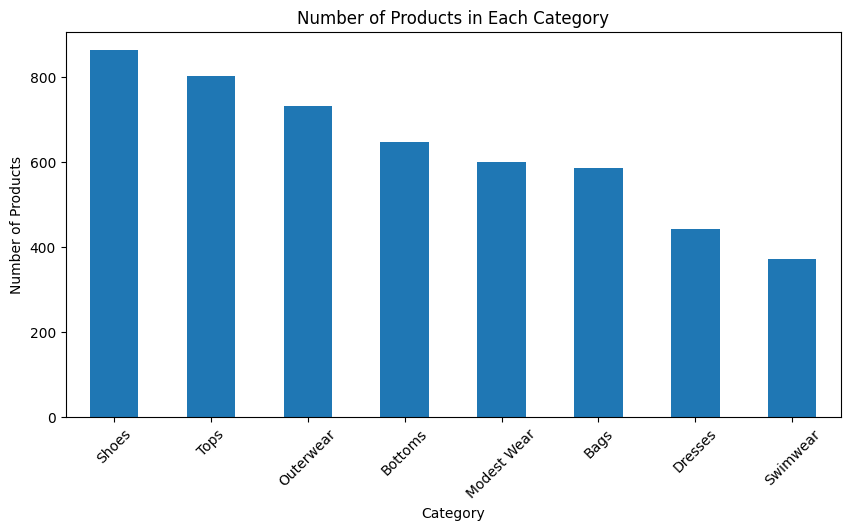

In [ ]:
category_counts=df["Category"].value_counts()
plt.figure(figsize=(10, 5))
category_counts.plot(kind="bar")
plt.title("Number of Products in Each Category")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

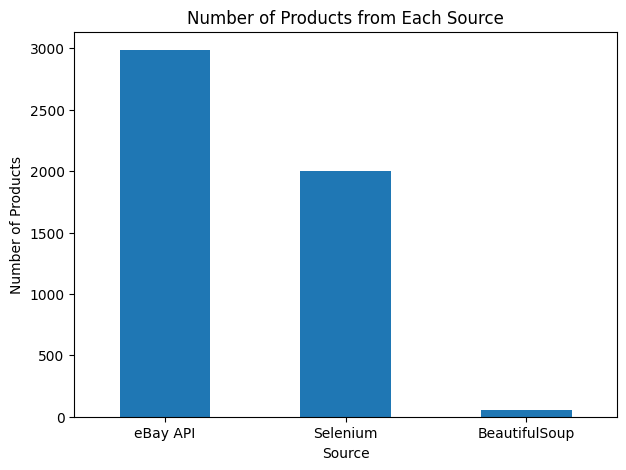

In [ ]:
source_counts=df["Source"].value_counts()
plt.figure(figsize=(7, 5))
source_counts.plot(kind="bar")
plt.title("Number of Products from Each Source")
plt.xlabel("Source")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()


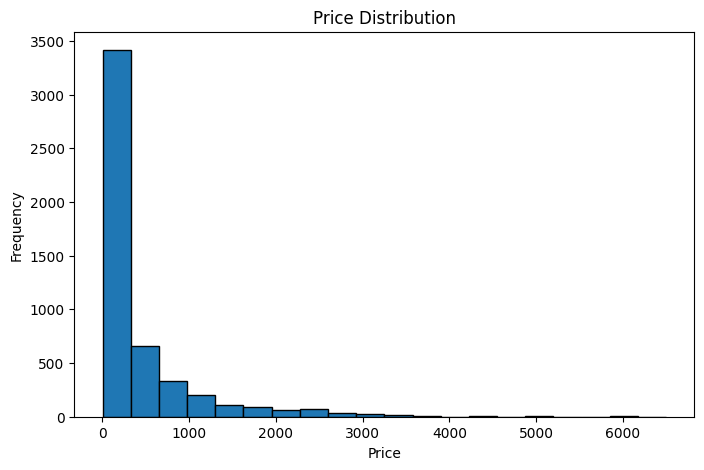

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(price_data["Price"], bins=20, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

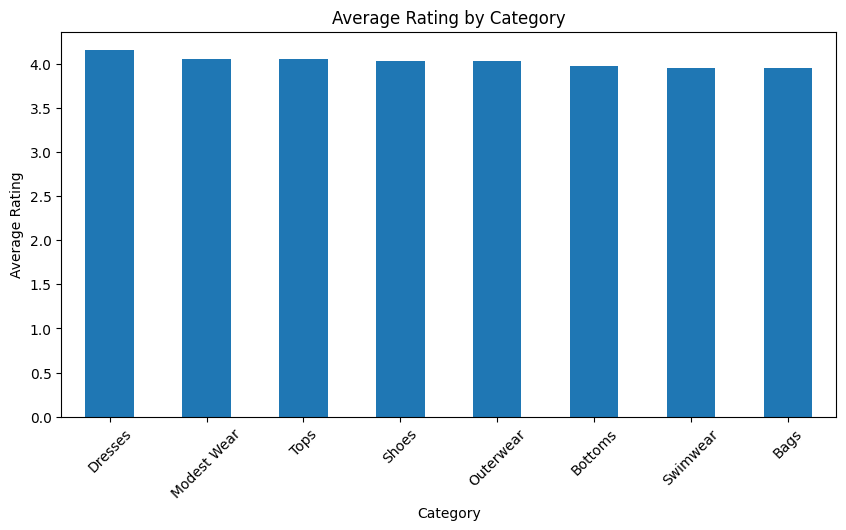

In [ ]:
category_rating=rating_data.groupby("Category")["Rating"].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
category_rating.plot(kind="bar")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

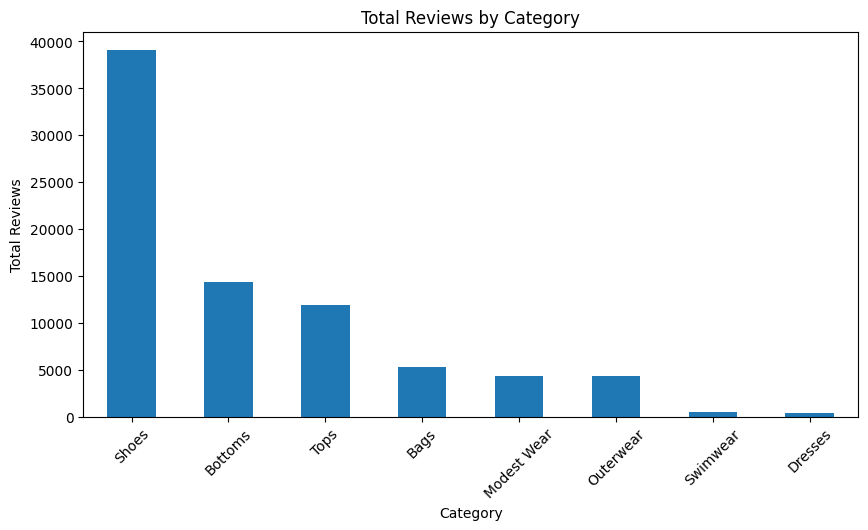

In [ ]:
category_reviews=df.groupby("Category")["Reviews"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
category_reviews.plot(kind="bar")
plt.title("Total Reviews by Category")
plt.xlabel("Category")
plt.ylabel("Total Reviews")
plt.xticks(rotation=45)
plt.show()

In [ ]:
fig=go.Figure(data=[go.Pie(
    labels=category_counts.index,
    values=category_counts.values,
    hole=0.35
)])
fig.update_layout(title="Products Distribution by Category")
fig.show()

# **Heatmap**


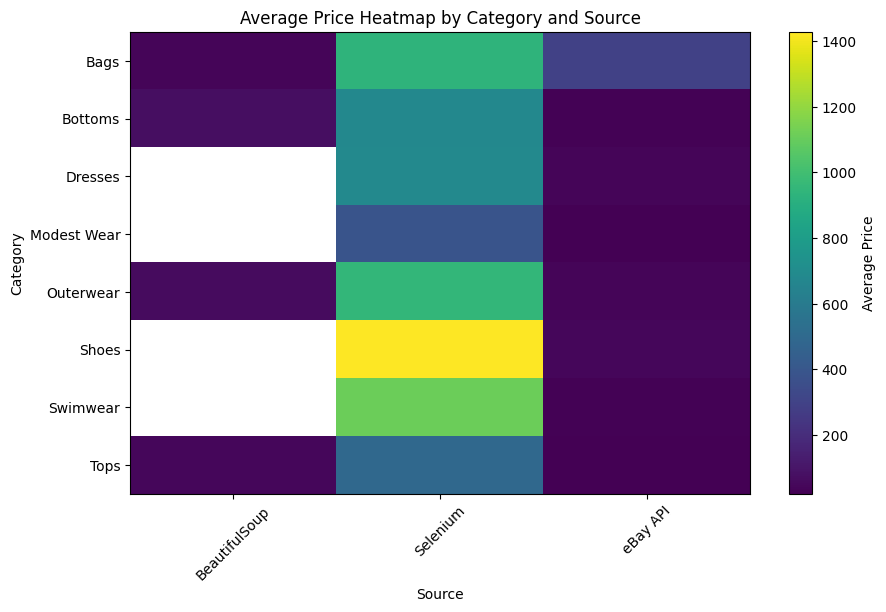

In [ ]:
pivot_table=price_data.pivot_table(
    values="Price",
    index="Category",
    columns="Source",
    aggfunc="mean"
)
plt.figure(figsize=(10, 6))
plt.imshow(pivot_table, aspect="auto")
plt.colorbar(label="Average Price")
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns, rotation=45)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.title("Average Price Heatmap by Category and Source")
plt.xlabel("Source")
plt.ylabel("Category")
plt.show()

# **Point Cloud**


In [ ]:
point_data=df.dropna(subset=["Price", "Rating"]).copy()
point_data=point_data[point_data["Reviews"] > 0]
fig=go.Figure(data=[go.Scatter3d(
    x=point_data["Price"],
    y=point_data["Rating"],
    z=point_data["Reviews"],
    mode="markers",
    text=point_data["Name"],
    marker=dict(size=4, opacity=0.65)
)])
fig.update_layout(
    title="Product Point Cloud: Price, Rating, and Reviews",
    scene=dict(
        xaxis_title="Price",
        yaxis_title="Rating",
        zaxis_title="Reviews"
    )
)
fig.show()

# **NetworkX Graph Construction**


In [ ]:
G=nx.Graph()
for i, row in df.iterrows():
    product=str(row["Name"])
    category=str(row["Category"])
    source=str(row["Source"])
    G.add_node(product, node_type="Product", price=row["Price"], rating=row["Rating"], reviews=row["Reviews"])
    G.add_node(category, node_type="Category")
    G.add_node(source, node_type="Source")
    G.add_edge(product, category, relation="belongs_to")
    G.add_edge(product, source, relation="collected_from")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 4536
Number of edges: 9067


In [ ]:
degree=dict(G.degree())
top_degree=sorted(degree.items(), key=lambda x: x[1], reverse=True)[:10]
df_degree=pd.DataFrame({
    "Node": [node for node, value in top_degree],
    "Type": [G.nodes[node].get("node_type") for node, value in top_degree],
    "Degree": [value for node, value in top_degree]
})
display(df_degree)

,Node,Type,Degree
0,eBay API,Source,2929
1,Selenium,Source,1545
2,Tops,Category,746
3,Shoes,Category,696
4,Outerwear,Category,666
5,Bottoms,Category,605
6,Bags,Category,529
7,Modest Wear,Category,522
8,Dresses,Category,416
9,Swimwear,Category,362


In [ ]:
betweenness=nx.betweenness_centrality(G, k=min(120, G.number_of_nodes()), seed=42)
top_betweenness=sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
df_betweenness=pd.DataFrame({
    "Node": [node for node, value in top_betweenness],
    "Type": [G.nodes[node].get("node_type") for node, value in top_betweenness],
    "Betweenness Centrality": [round(value, 4) for node, value in top_betweenness]
})
display(df_betweenness)

,Node,Type,Betweenness Centrality
0,eBay API,Source,0.6866
1,Selenium,Source,0.2146
2,Tops,Category,0.1055
3,Shoes,Category,0.1022
4,Outerwear,Category,0.0841
5,Bottoms,Category,0.0596
6,Bags,Category,0.0576
7,Modest Wear,Category,0.0445
8,Dresses,Category,0.0179
9,Swimwear,Category,0.0133


# **Communities**


In [ ]:
sample_df=df.sample(min(300, len(df)), random_state=42)
G_sample=nx.Graph()
for i, row in sample_df.iterrows():
    product=str(row["Name"])
    if len(product) > 28:
        product=product[:25] + "..."
    category=str(row["Category"])
    source=str(row["Source"])
    G_sample.add_node(product, node_type="Product")
    G_sample.add_node(category, node_type="Category")
    G_sample.add_node(source, node_type="Source")
    G_sample.add_edge(product, category)
    G_sample.add_edge(product, source)
communities=list(nx.community.greedy_modularity_communities(G_sample))
print("Number of communities in sample graph:", len(communities))
community_rows=[]
for idx, community in enumerate(communities[:10], start=1):
    community_rows.append({
        "Community": idx,
        "Size": len(community),
        "Main Nodes": ", ".join(list(community)[:6])
    })
df_communities=pd.DataFrame(community_rows)
display(df_communities)

Number of communities in sample graph: 6


,Community,Size,Main Nodes
0,1,78,"half boot for women 685, Dejavu Shoes GPS DVTX..."
1,2,59,"Altardstate - Willa Strap..., Ivory Ribbed Twi..."
2,3,57,"SHWODAY Sleeves Athletic ..., Muji Women's Fla..."
3,4,43,"CAESAR WOMEN WOOL PULLOVE..., Mobaco Women Qui..."
4,5,42,"Leggings Stretch Comforta..., adidas Female ES..."
5,6,27,"Mila Handmade Cotton Moda..., LOVARZI Blue Sca..."


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127381 (\N{SQUARED NEW}) missing from font(s) DejaVu Sans.



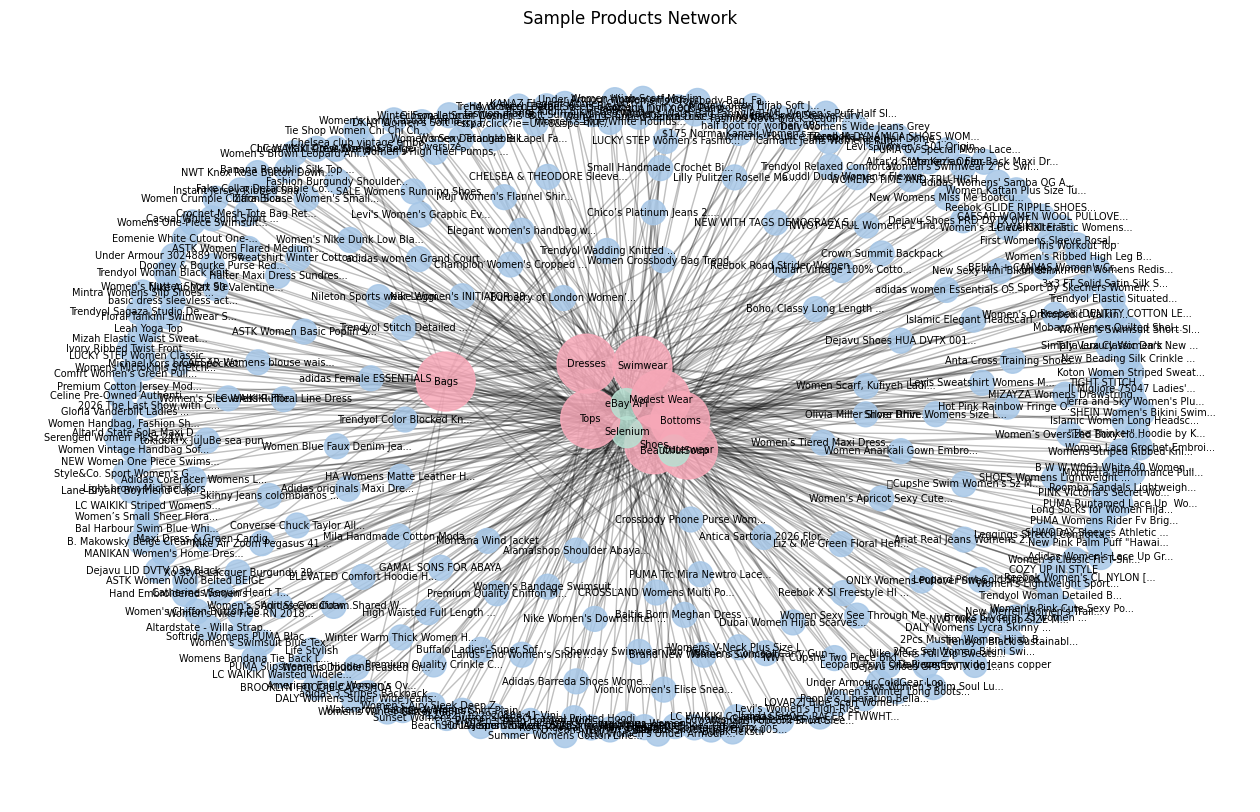

In [ ]:
plt.figure(figsize=(16, 10))
pos=nx.spring_layout(G_sample, k=0.7, seed=42)
node_colors=[]
node_sizes=[]
for node in G_sample.nodes():
    node_type = G_sample.nodes[node].get("node_type")
    if node_type=="Category":
        node_colors.append("#f7a8b8")
        node_sizes.append(1800)
    elif node_type=="Source":
        node_colors.append("#b8e0d2")
        node_sizes.append(500)
    else:
        node_colors.append("#a7c7e7")
        node_sizes.append(320)
nx.draw_networkx_nodes(G_sample, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G_sample, pos, alpha=0.25)
nx.draw_networkx_labels(G_sample, pos, font_size=7)
plt.title("Sample Products Network")
plt.axis("off")
plt.show()


# **Final Insights**


In [ ]:
print("Project Insights")
print("----------------")
print("Total products collected:", len(df))
print("Number of categories:", df["Category"].nunique())
print("Number of sources:", df["Source"].nunique())
print("Most common category:", df["Category"].value_counts().idxmax())
print("Most used source:", df["Source"].value_counts().idxmax())
print("Average price:", round(price_data["Price"].mean(), 2))
print("Highest price:", price_data["Price"].max())
print("Lowest price:", price_data["Price"].min())
print("Average rating:", round(rating_data["Rating"].mean(), 2))
print("Highest rating:", rating_data["Rating"].max())
print("Products with reviews:", len(reviews_data))
print("Total reviews:", reviews_data["Reviews"].sum())
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Project Insights
----------------
Total products collected: 5037
Number of categories: 8
Number of sources: 3
Most common category: Shoes
Most used source: eBay API
Average price: 391.92
Highest price: 6500.0
Lowest price: 2.0
Average rating: 4.02
Highest rating: 5.0
Products with reviews: 1584
Total reviews: 80330
Graph nodes: 4536
Graph edges: 9067


In [ ]:
df_degree.to_csv("top_degree_nodes.csv", index=False, encoding="utf-8-sig")
df_betweenness.to_csv("top_betweenness_nodes.csv", index=False, encoding="utf-8-sig")
category_summary.to_csv("category_summary.csv", encoding="utf-8-sig")

# **Bonus: Simple Interactive Dashboard**


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
categories=["All"] + sorted(df["Category"].dropna().unique().tolist())
sources=["All"] + sorted(df["Source"].dropna().unique().tolist())
category_dropdown=widgets.Dropdown(options=categories, value="All", description="Category:")
source_dropdown=widgets.Dropdown(options=sources, value="All", description="Source:")
out=widgets.Output()
def show_summary(change=None):
    temp=df.copy()
    if category_dropdown.value != "All":
        temp=temp[temp["Category"]==category_dropdown.value]
    if source_dropdown.value != "All":
        temp=temp[temp["Source"]==source_dropdown.value]
    with out:
        clear_output(wait=True)
        print("Filtered Products:", len(temp))
        print("Categories:", temp["Category"].nunique())
        print("Sources:", temp["Source"].nunique())
        if len(temp.dropna(subset=["Price"])) > 0:
            print("Average Price:", round(temp["Price"].mean(), 2))
        if len(temp.dropna(subset=["Rating"])) > 0:
            print("Average Rating:", round(temp["Rating"].mean(), 2))
        print("Total Reviews:", temp["Reviews"].sum())
        display(temp[["Name", "Category", "Source", "Price", "Rating", "Reviews"]].head(10))
category_dropdown.observe(show_summary, names="value")
source_dropdown.observe(show_summary, names="value")
display(category_dropdown, source_dropdown, out)
show_summary()

Dropdown(description='Category:', options=('All', 'Bags', 'Bottoms', 'Dresses', 'Modest Wear', 'Outerwear', 'S…

Dropdown(description='Source:', options=('All', 'BeautifulSoup', 'Selenium', 'eBay API'), value='All')

Output()

In [ ]:
fig=go.Figure(data=[go.Bar(
    x=df["Category"].value_counts().index,
    y=df["Category"].value_counts().values
)])
fig.update_layout(
    title="Interactive Category Distribution",
    xaxis_title="Category",
    yaxis_title="Number of Products"
)
fig.show()

In [ ]:
top_reviews=df[df["Reviews"] > 0].sort_values(by="Reviews", ascending=False).head(10)
fig=go.Figure(data=[go.Bar(
    x=top_reviews["Reviews"],
    y=top_reviews["Name"],
    orientation="h"
)])
fig.update_layout(
    title="Top 10 Most Reviewed Products",
    xaxis_title="Reviews",
    yaxis_title="Product"
)
fig.show()